In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

In [43]:
csv='used_cars_mock.xls'
df=pd.read_csv(csv)
df

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Toyota,Model A,2025,13572.0,Petrol,Manual,5,30,23215
9996,9997,Toyota,Model B,2025,0.0,Petrol,Manual,7,1,26088
9997,9998,Fiat,Model A,2025,0.0,Petrol,Manual,12,30,20601
9998,9999,Toyota,Model B,2021,53390.0,Petrol,Manual,12,10,10563


In [44]:
df.tail()

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
9995,9996,Toyota,Model A,2025,13572.0,Petrol,Manual,5,30,23215
9996,9997,Toyota,Model B,2025,0.0,Petrol,Manual,7,1,26088
9997,9998,Fiat,Model A,2025,0.0,Petrol,Manual,12,30,20601
9998,9999,Toyota,Model B,2021,53390.0,Petrol,Manual,12,10,10563
9999,10000,Honda,Model A,2017,88837.0,Diesel,Automatic,1,30,4710


# ***List of Issues***
- 1 Missing and Invalid Mileage Values
  
The mileage column contains null values and negative values, which are not valid in real-world scenarios.

- 2 Incorrect Category in Fuel Type
  
The fuel_type column contains an invalid entry (“xyz”), which does not represent any real fuel category.

- 3 Unrealistic Price Values
  
Some cars have prices like 0 and 500, which are not possible in real life and indicate data entry errors.

- 4 Future Year Values

The dataset contains car selling years like 2030, which is unrealistic and incorrect.

- 5 Extreme Outlier in Price
  
A car (Honda) has a price of 999999, which is an extreme outlier and not practical.

- 6 Extreme Values in Mileage

The mileage column contains extreme values at both lower and higher ends, which can distort analysis and need to be treated.

In [45]:
df.describe(
)

,car_id,year,mileage,sale_month,zip_prefix,price
count,10000.00000,10000.000000,9694.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,2019.804700,62036.526718,6.738100,15.42200,15278.148600
std,2886.89568,6.324884,71546.816912,3.581451,11.57261,13725.370724
min,1.00000,2000.000000,-500.000000,1.000000,1.00000,0.000000
25%,2500.75000,2018.000000,7771.000000,4.000000,1.00000,6761.500000
50%,5000.50000,2022.000000,35781.500000,7.000000,20.00000,15852.000000
75%,7500.25000,2025.000000,87767.500000,10.000000,30.00000,23125.000000
max,10000.00000,2030.000000,250000.000000,12.000000,30.00000,999999.000000


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        10000 non-null  int64  
 1   brand         10000 non-null  object 
 2   model         10000 non-null  object 
 3   year          10000 non-null  int64  
 4   mileage       9694 non-null   float64
 5   fuel_type     10000 non-null  object 
 6   transmission  10000 non-null  object 
 7   sale_month    10000 non-null  int64  
 8   zip_prefix    10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


# ***Feature Engineering (New Column Creation)***
- Created a new column car_age using:
- car_age = current_year - year

In [47]:
from datetime import datetime   
current_year = datetime.now().year


df["car_age"] = current_year - df["year"]


print(df.head())


df.to_csv("used_cars_updated.csv", index=False)

   car_id  brand    model  year   mileage fuel_type transmission  sale_month  \
0       1  Honda  Model A  2020   50757.0    Petrol       Manual           7   
1       2   Fiat  Model B  2030       NaN    Hybrid    Automatic           1   
2       3   Audi  Model C  2025    -500.0    Petrol    Automatic          12   
3       4     VW  Model B  2023   10661.0       XYZ    Automatic          10   
4       5  Dacia  Model C  2015  126515.0    Petrol       Manual           7   

   zip_prefix   price  car_age  
0          30  999999        6  
1           1   19076       -4  
2           1   29629        1  
3          20   18132        3  
4          30       0       11  


- A new column car_age is created by subtracting the car's manufacturing year from the current year, which helps analyze how the age of a car affects factors like price and mileage in the dataset

# ***Handling Invalid Year Values***
- Removed rows where the manufacturing year was greater than the current year (2026).
These were unrealistic future values.

In [48]:
df = df[df["year"] <= 2026]

- Rows where the year > 2026 were deleted as they represent future or incorrect car manufacturing years.

# ***Cleaning Mileage Column***
- Replaced invalid mileage values (null, 0, negative) with NaN
- Filled missing values using:
- Average mileage based on brand and car age
- This ensures realistic and meaningful data.

In [49]:
import numpy as np

# IMPORTANT: make a copy to avoid warning
df_clean = df.copy()

# Step 1: Replace invalid mileage
df.loc[df['mileage'] <= 0, 'mileage'] = np.nan

# Step 2: Create car_age
current_year = 2026
df.loc[:, 'car_age'] = current_year - df['year']

# Step 3: Fill using brand + car_age mean
df.loc[:, 'mileage'] = df.groupby(['brand', 'car_age'])['mileage'].transform(
    lambda x: x.fillna(x.mean())
)

# Step 4: Final fallback (median)
df.loc[:, 'mileage'] = df['mileage'].fillna(df['mileage'].median())

In [50]:
df_clean

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999,6
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629,1
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132,3
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0,11
5,6,VW,Model C,2015,121974.0,Petrol,Manual,12,1,500,11
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Toyota,Model A,2025,13572.0,Petrol,Manual,5,30,23215,1
9996,9997,Toyota,Model B,2025,0.0,Petrol,Manual,7,1,26088,1
9997,9998,Fiat,Model A,2025,0.0,Petrol,Manual,12,30,20601,1
9998,9999,Toyota,Model B,2021,53390.0,Petrol,Manual,12,10,10563,5


- To improve data quality, invalid values in the mileage column such as null, zero, and negative values were identified and treated as missing data. These values were then replaced using the average mileage calculated for each car brand and car age group, ensuring more realistic and consistent mileage values for further analysis.

# ***Fixing Fuel Type Column***
- Checked unique values in fuel_type
- Found invalid value "xyz"
- Replaced it with "Petrol" based on domain knowledge:
- Most 2023 automatic cars (especially Volkswagen) are petrol-based

In [51]:
df['fuel_type'].unique()

array(['Petrol', 'XYZ', 'Hybrid', 'Diesel'], dtype=object)

In [52]:
df[df['fuel_type'].str.contains('xyz', case=False, na=False)]

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132,3


- In 2023, most automatic Volkswagen(VW) cars are petrol-powered

In [53]:
df.loc[df['fuel_type'].str.contains('xyz', case=False, na=False), 'fuel_type'] = 'Petrol'

In [54]:
df.head()

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
0,1,Honda,Model A,2020,50757.000000,Petrol,Manual,7,30,999999,6
2,3,Audi,Model C,2025,12381.708333,Petrol,Automatic,12,1,29629,1
3,4,VW,Model B,2023,10661.000000,Petrol,Automatic,10,20,18132,3
4,5,Dacia,Model C,2015,126515.000000,Petrol,Manual,7,30,0,11
5,6,VW,Model C,2015,121974.000000,Petrol,Manual,12,1,500,11


- Invalid entries in the fuel_type column, such as ‘xyz’, were replaced with ‘Petrol’ based on domain knowledge

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.head()

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
0,1,Honda,Model A,2020,50757.000000,Petrol,Manual,7,30,999999,6
2,3,Audi,Model C,2025,12381.708333,Petrol,Automatic,12,1,29629,1
3,4,VW,Model B,2023,10661.000000,Petrol,Automatic,10,20,18132,3
4,5,Dacia,Model C,2015,126515.000000,Petrol,Manual,7,30,0,11
5,6,VW,Model C,2015,121974.000000,Petrol,Manual,12,1,500,11


# ***Removing Illogical Data***
- Removed records where:
- Car age > 15 years AND fuel type = Diesel
- This combination is less relevant or unrealistic in modern datasets

In [57]:
# remove cars jinki age > 15 aur fuel diesel hai
df_clean1 = df[~((df["car_age"] > 15) & (df["fuel_type"] == "Diesel"))]

print(df_clean1)

      car_id   brand    model  year        mileage fuel_type transmission  \
0          1   Honda  Model A  2020   50757.000000    Petrol       Manual   
2          3    Audi  Model C  2025   12381.708333    Petrol    Automatic   
3          4      VW  Model B  2023   10661.000000    Petrol    Automatic   
4          5   Dacia  Model C  2015  126515.000000    Petrol       Manual   
5          6      VW  Model C  2015  121974.000000    Petrol       Manual   
...      ...     ...      ...   ...            ...       ...          ...   
9995    9996  Toyota  Model A  2025   13572.000000    Petrol       Manual   
9996    9997  Toyota  Model B  2025   12152.085714    Petrol       Manual   
9997    9998    Fiat  Model A  2025   11392.879310    Petrol       Manual   
9998    9999  Toyota  Model B  2021   53390.000000    Petrol       Manual   
9999   10000   Honda  Model A  2017   88837.000000    Diesel    Automatic   

      sale_month  zip_prefix   price  car_age  
0              7          3

- This code filters the dataset to remove diesel cars older than 15 years using car_age and fuel_type conditions.
A cleaned dataset df_clean1 is created that excludes these outdated diesel vehicles for better data quality and analysis.

In [58]:
df_clean1.shape

(9740, 11)

# Removal of Older Petrol Vehicles (Age > 15 Years)

In [59]:
# remove petrol cars whose age > 15 (permanent)
df_clean1 = df_clean1[~((df_clean1["car_age"] > 15) & 
                        (df_clean1["fuel_type"] == "Petrol"))]

- This operation filters the dataset to remove petrol fuel type cars that are older than 15 years using car_age and fuel_type conditions.
A new cleaned dataset is created without these outdated petrol cars for better data quality.

In [60]:
df_clean1.shape

(8978, 11)

In [61]:
df_clean = df_clean1[~((df_clean1["car_age"] > 20) & 
                        (df_clean1["fuel_type"] == "Hybrid"))]

- Hybrid vehicles with an age greater than 20 years were removed to eliminate unrealistic or less relevant entries, as hybrid technology is relatively recent and battery performance declines over time. A case-insensitive condition was applied to ensure accurate filtering and improve overall data quality.

In [62]:
df_clean.shape

(8910, 11)

In [63]:
df_clean.head()

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
0,1,Honda,Model A,2020,50757.000000,Petrol,Manual,7,30,999999,6
2,3,Audi,Model C,2025,12381.708333,Petrol,Automatic,12,1,29629,1
3,4,VW,Model B,2023,10661.000000,Petrol,Automatic,10,20,18132,3
4,5,Dacia,Model C,2015,126515.000000,Petrol,Manual,7,30,0,11
5,6,VW,Model C,2015,121974.000000,Petrol,Manual,12,1,500,11


In [64]:
df_clean = df_clean.drop(index=0)

In [65]:
df_clean.shape

(8909, 11)

- I removed the Honda Model A entries because the price value (999999) was identified as an extreme outlier.
  
- This value was significantly higher than the normal price range and could distort the analysis.

## ***Handling Invalid Vaues and Outliers in Price Column***

In [66]:
import numpy as np

# STEP 1: Mark missing + extreme values as NaN
df_clean.loc[(df_clean['price'] <= 0) | (df_clean['price'].isna()), 'price'] = np.nan


# STEP 2: Create group-wise average (brand + car_age)
group_avg = df_clean.groupby(['brand', 'car_age'])['price'].transform('mean')


# STEP 3: Fill NaN with group average
df_clean['price'] = df_clean['price'].fillna(group_avg)


# STEP 4: If still NaN (rare case), fill with brand average
brand_avg = df_clean.groupby('brand')['price'].transform('mean')
df_clean['price'] = df_clean['price'].fillna(brand_avg)


# STEP 5: Final fallback → overall median
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())

- Missing and invalid price values (such as zero or negative values) were first converted into null values to ensure data consistency.
- Then, prices were imputed using the average price of similar cars based on brand and car age, which improves accuracy.
- For remaining missing values, the brand-level average was used as a fallback to maintain logical grouping.
- Finally, any leftover null values were filled using the overall median price to avoid data loss.
This step ensures a complete dataset and improves the reliability of further analysis and modeling.

In [67]:
df_clean

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
2,3,Audi,Model C,2025,12381.708333,Petrol,Automatic,12,1,29629.000000,1
3,4,VW,Model B,2023,10661.000000,Petrol,Automatic,10,20,18132.000000,3
4,5,Dacia,Model C,2015,126515.000000,Petrol,Manual,7,30,2967.615385,11
5,6,VW,Model C,2015,121974.000000,Petrol,Manual,12,1,500.000000,11
7,8,Ford,Model B,2025,3210.000000,Hybrid,Automatic,11,1,21820.000000,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Toyota,Model A,2025,13572.000000,Petrol,Manual,5,30,23215.000000,1
9996,9997,Toyota,Model B,2025,12152.085714,Petrol,Manual,7,1,26088.000000,1
9997,9998,Fiat,Model A,2025,11392.879310,Petrol,Manual,12,30,20601.000000,1
9998,9999,Toyota,Model B,2021,53390.000000,Petrol,Manual,12,10,10563.000000,5


In [68]:
df_clean[df_clean['price'] < 10000] # check how many car price les than 10000

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,car_age
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,2967.615385,11
5,6,VW,Model C,2015,121974.0,Petrol,Manual,12,1,500.000000,11
13,14,Toyota,Model A,2017,95659.0,Diesel,Manual,2,1,6814.000000,9
14,15,VW,Model A,2016,97948.0,Petrol,Manual,3,1,9107.000000,10
15,16,BMW,Model C,2016,121680.0,Petrol,Manual,9,1,4388.000000,10
...,...,...,...,...,...,...,...,...,...,...,...
9975,9976,Mercedes,Model C,2016,120555.0,Petrol,Manual,4,10,4090.000000,10
9982,9983,Hyundai,Model B,2020,64093.0,Hybrid,Automatic,4,10,9369.000000,6
9987,9988,Fiat,Model A,2019,58236.0,Petrol,Automatic,7,10,7555.000000,7
9994,9995,Honda,Model B,2012,156731.0,Diesel,Automatic,12,20,500.000000,14


In [69]:
df_clean = df_clean[df_clean['price'] >= 5000]

- cars with a price lower than 5,000 were removed from the dataset using a filtering condition. Extremely low prices may indicate data entry errors, unrealistic listings, or incomplete records. By keeping only records with price ≥ 5,000, the dataset becomes more reliable and suitable for analysis. This step helps ensure that the EDA results and price trends reflect more realistic used car market values.

In [70]:
df_clean.shape

(7909, 11)

In [71]:
df_clean["price"].isna().sum() 

np.int64(0)

In [72]:
df_clean['mileage'].isna().sum()

np.int64(0)

# ***Univariate Analysis (One variable analysis)***

## ***Price Distribution Analysis Using Boxplot***
- A boxplot of car prices
- Median price (middle line)
- Spread of prices (IQR: middle 50%)
- Outliers (very high or very low prices

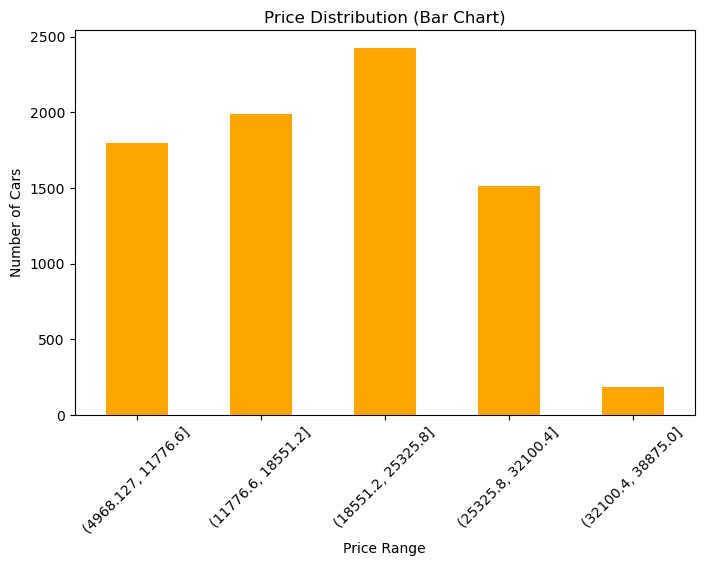

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

# Create price ranges (bins)
price_bins = pd.cut(df_clean['price'], bins=5)

# Count values in each bin
price_counts = price_bins.value_counts().sort_index()

plt.figure(figsize=(8,5))

price_counts.plot(
    kind='bar',
    color='orange'
)

plt.title("Price Distribution (Bar Chart)")
plt.xlabel("Price Range")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)
plt.show()

- The chart shows a right-skewed frequency distribution where most cars are mid-priced ($18k–$25k), with a sharp decline in availability for high-end models.

# ***Distribution of Cars by Manufacturing Year***
- A bar chart of car counts by year
- Which years have more listed cars
- Distribution of cars across different model years
- Market availability trend over time

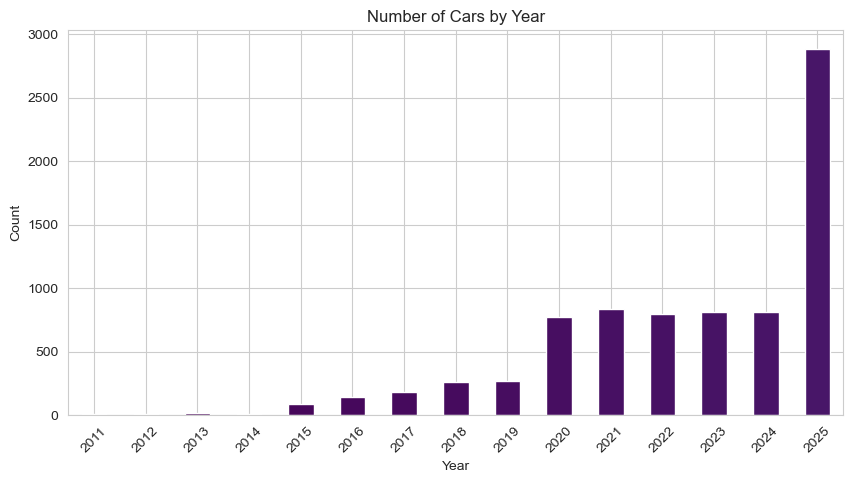

In [332]:

import matplotlib.pyplot as plt

year_count = df_clean['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

# colorful bars
year_count.plot(
    kind='bar',
    color=plt.cm.viridis(range(len(year_count)))  # color gradient
)

plt.title("Number of Cars by Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()


- The bar chart illustrates the distribution of car sales by year. It is evident that 2025 recorded the highest number of car sales among all the years

# ***Mileage Distribution***

<Axes: xlabel='mileage', ylabel='Count'>

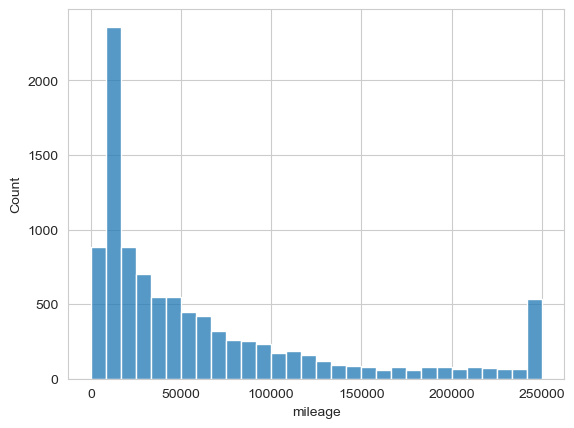

In [312]:

sns.histplot(df_clean["mileage"], bins=30)


- The mileage distribution shows that most cars have moderate mileage, indicating typical vehicle usage.
- The distribution is right-skewed, meaning a few cars have very high mileage compared to the majority.
- Higher mileage vehicles may have lower resale value, making mileage an important factor in price analysis.

# ***Car Age Distribution***

<Axes: xlabel='car_age', ylabel='Count'>

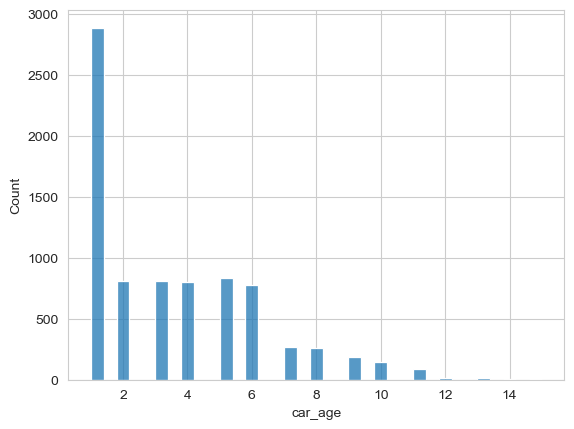

In [330]:
sns.histplot(df_clean["car_age"])

- The histogram shows the distribution of the car_age variable in the dataset. Most cars are relatively new (around 1–5 years old), which is indicated by the highest frequency in the lower age range. The distribution is right-skewed (positive skewness), meaning there are fewer older cars but the age extends up to around 10+ years. This suggests that the dataset is dominated by newer vehicles, while very old cars appear less frequently.

## ***Fuel Type-wise Car Count Analysis***
A count plot of different fuel types (Petrol, Diesel, CNG, etc.)

- Which fuel type is most common
- Market preference of fuel usage
- Composition of your dataset based on fuel category

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13484\3571151529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


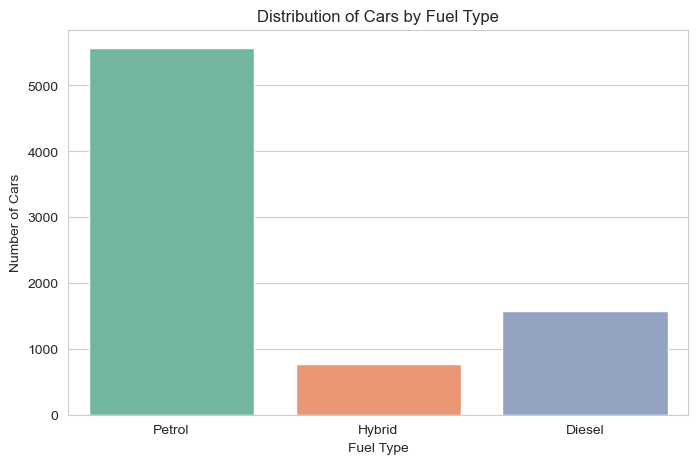

In [314]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="fuel_type",
    palette="Set2"
)

plt.title("Distribution of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

- The dataset is heavily dominated by Petrol vehicles, which comprise approximately 5,600 units, significantly outnumbering other fuel types. Diesel cars hold the second-largest share with around 1,550 listings, while Hybrid vehicles remain the least common at roughly 750 units. This distribution highlights a used car market still primarily concentrated on traditional internal combustion engines rather than alternative fuel options.

## ***Percentage Share of Car Fuel Types***
### ***A pie chart of fuel type distribution***
- Which fuel type is most common
- Percentage share of each fuel category (Petrol, Diesel, etc.)
- Overall fuel composition in the dataset
- Market preference of fuel usage

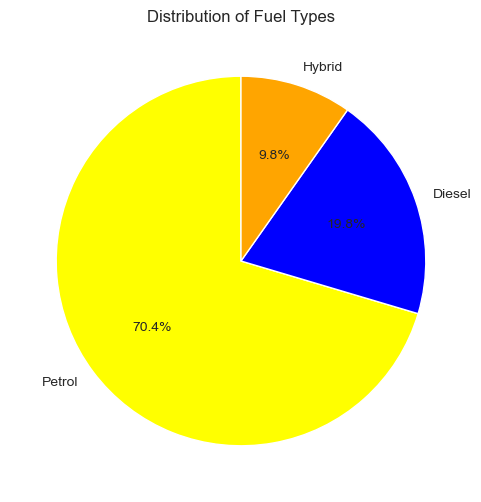

In [315]:
import matplotlib.pyplot as plt

# count fuel types
fuel_count = df_clean['fuel_type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fuel_count,
    labels=fuel_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['yellow', 'blue', 'orange']  
)

plt.title("Distribution of Fuel Types")

plt.show()

- This pie chart shows that most used cars in the dataset are petrol type (70.4%), followed by diesel (19.8%) and hybrid (9.8%).
- It indicates that petrol cars dominate the dataset, while diesel and hybrid vehicles have a smaller share.
- This distribution helps in understanding the overall fuel type preference in the dataset.

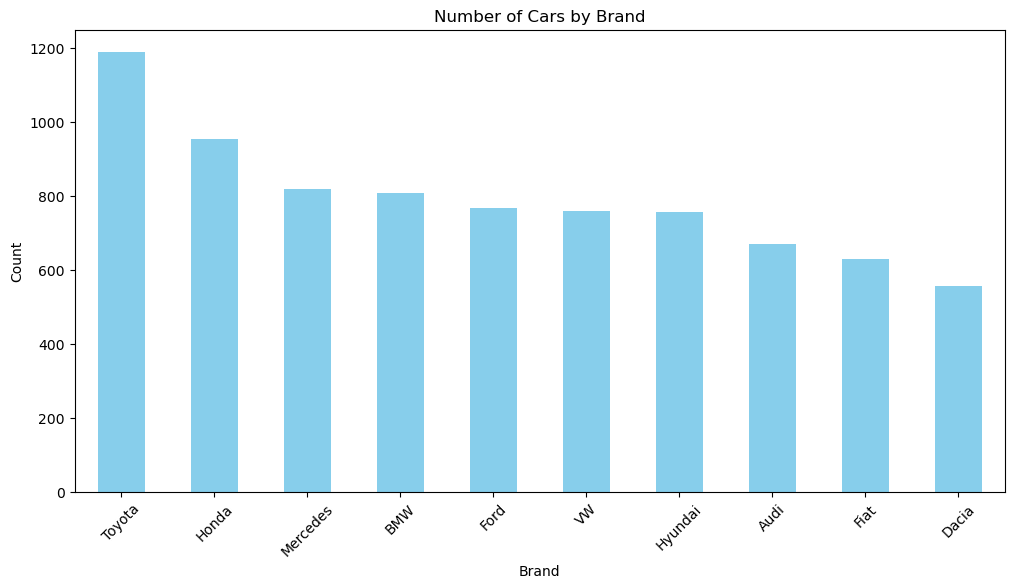

In [74]:
import matplotlib.pyplot as plt

# count cars per brand
brand_count = df_clean['brand'].value_counts()

plt.figure(figsize=(12,6))

brand_count.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Number of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

- This bar chart displays the categorical frequency distribution of car brands, illustrating that Toyota is the most prevalent brand in the dataset with nearly 1,200 units, followed by a steady decline across other major manufacturers like Honda and Mercedes.

 # ***Bivariate Analysis: Relationship Between Variables***

## ***Year-wise Average Price Analysis***
### ***A line chart of average price vs year***
- Whether newer cars are more expensive
- Price trend over time (increase or decrease)
- Market value variation based on car age
- Relationship between year and pric

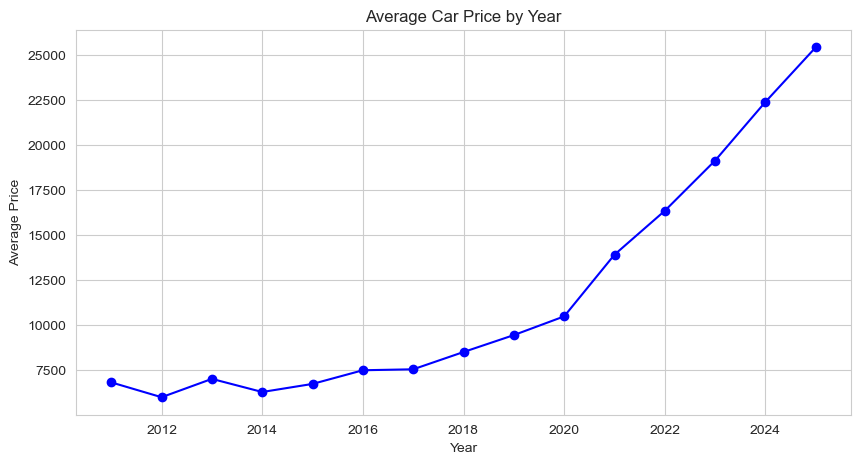

In [316]:
import matplotlib.pyplot as plt

# average price by year
year_avg_price = df_clean.groupby('year')['price'].mean().sort_index()

plt.figure(figsize=(10,5))

year_avg_price.plot(
    kind='line',
    marker='o',
    color='blue'   
)

plt.title("Average Car Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price")

plt.grid(True)
plt.show()

- The line graph illustrates the trend of average car prices over time.  followed by moderate fluctuations in the subsequent years. From 2016 to 2025, a significant upward trend is observed, with prices reaching their peak in 2024

## ***Model-wise Price Comparison***
### ***A bar chart of average price per car model***
- Which models are most expensive on average
- Which models are budget-friendly
- Price comparison across different car models
- Market value differences between models

model
Model C    18760.308519
Model B    18712.834193
Model A    18632.516029
Name: price, dtype: float64


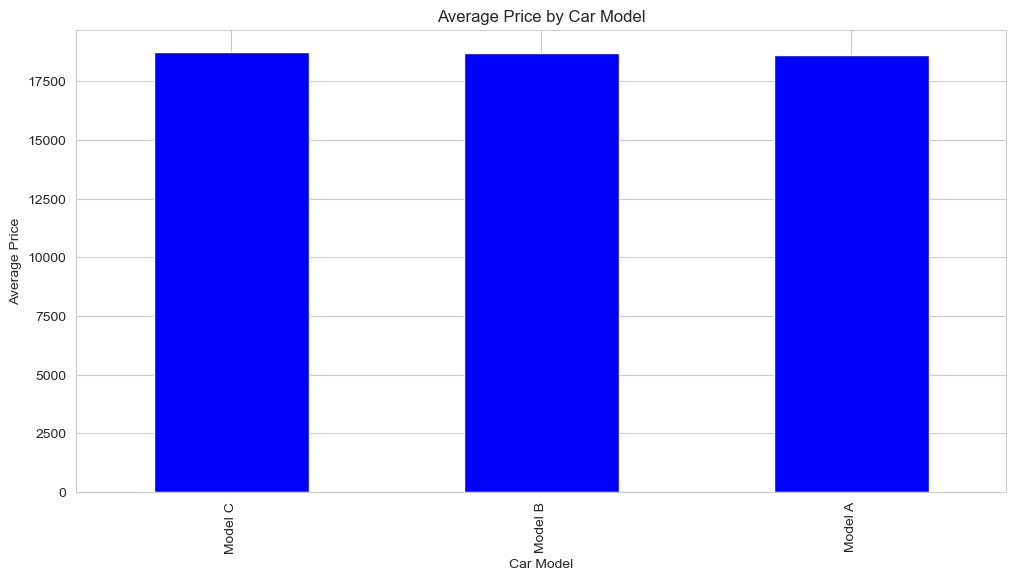

In [317]:
model_avg_price = df_clean.groupby('model')['price'].mean().sort_values(ascending=False)

print(model_avg_price)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

model_avg_price.plot(
    kind='bar',
    color='blue'
)

plt.title("Average Price by Car Model")
plt.xlabel("Car Model")
plt.ylabel("Average Price")

plt.xticks(rotation=90)
plt.show()

- The bar chart represents the average selling prices of selected car models, including Model C
, Model B, and Model A, highlighting the variation in pricing across different models


## ***Impact of Mileage on Car Price***
### ***A scatter plot of Mileage vs Price***
- Whether cars with higher mileage have lower prices
- Relationship (correlation) between usage and value
- Price variation at different mileage levels
- Presence of any unusual patterns or outliers

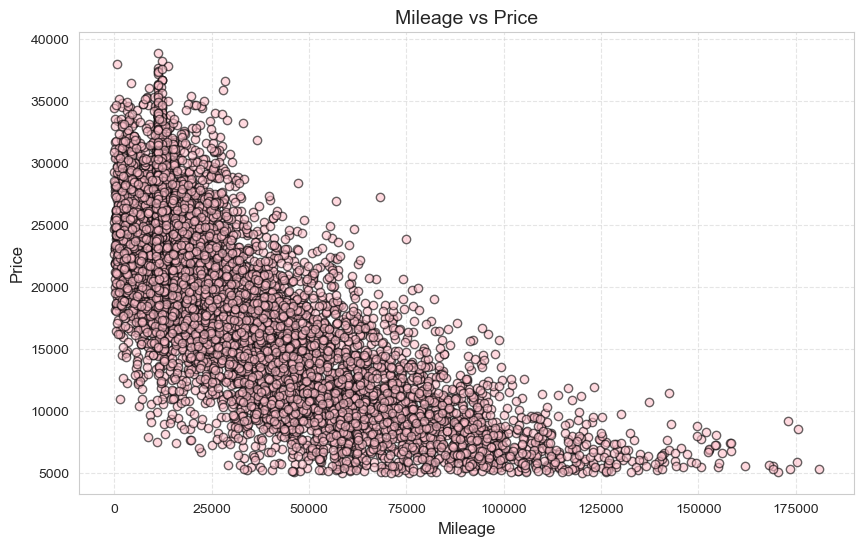

In [318]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df_clean['mileage'],
    df_clean['price'],
    color='pink',
    alpha=0.6,
    edgecolor='black'   # points clear dikhenge
)

plt.title("Mileage vs Price", fontsize=14)
plt.xlabel("Mileage", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)  # background grid

plt.show()

***PATTERN 2:***
As mileage increases, price decreases
- 0–30,000 km → high price (~25–35$)

- 50,000–100,000 km → medium price (~10-20$)

- 100,000+ km → low price (~5–10$)

## ***Car Depreciation Analysis Using Age vs Price***
### ***A scatter plot of Car Age vs Price***
- How price changes as a car gets older
- Whether older cars are cheaper
- Depreciation pattern of cars
- Spread and variation of price across different ages

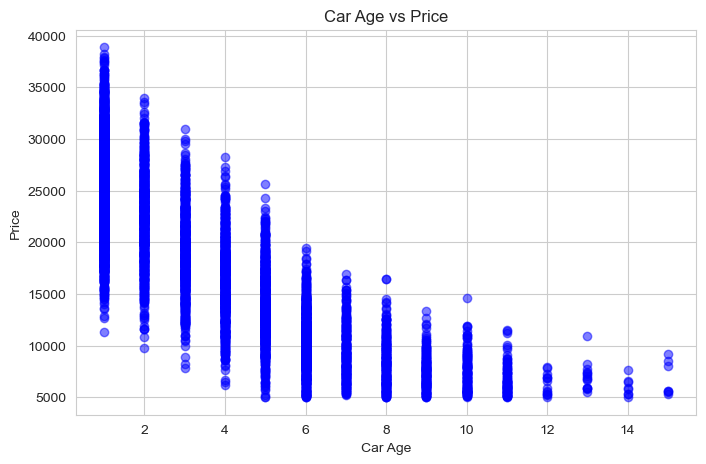

In [319]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_clean['car_age'],
    df_clean['price'],
    color='blue',
    alpha=0.5
)

plt.title("Car Age vs Price")
plt.xlabel("Car Age")
plt.ylabel("Price")

plt.show()

***Pattern 2***: Used car prices decline by approximately 10–15% per year, with higher depreciation observed in the initial years

## ***Car Usage Analysis Across Brands***
### ***A bar chart of average mileage per car brand***
- Which brands have higher or lower average mileage
- Usage pattern of different car brands
- How much cars of each brand are typically driven
- Brand-wise performance in terms of usage efficiency

brand
Mercedes    37658.968785
Audi        36776.387081
Honda       36472.639602
VW          35278.209386
Toyota      34544.705861
Ford        33361.035878
BMW         33351.368895
Hyundai     31256.026682
Fiat        30963.624164
Dacia       29965.632582
Name: mileage, dtype: float64


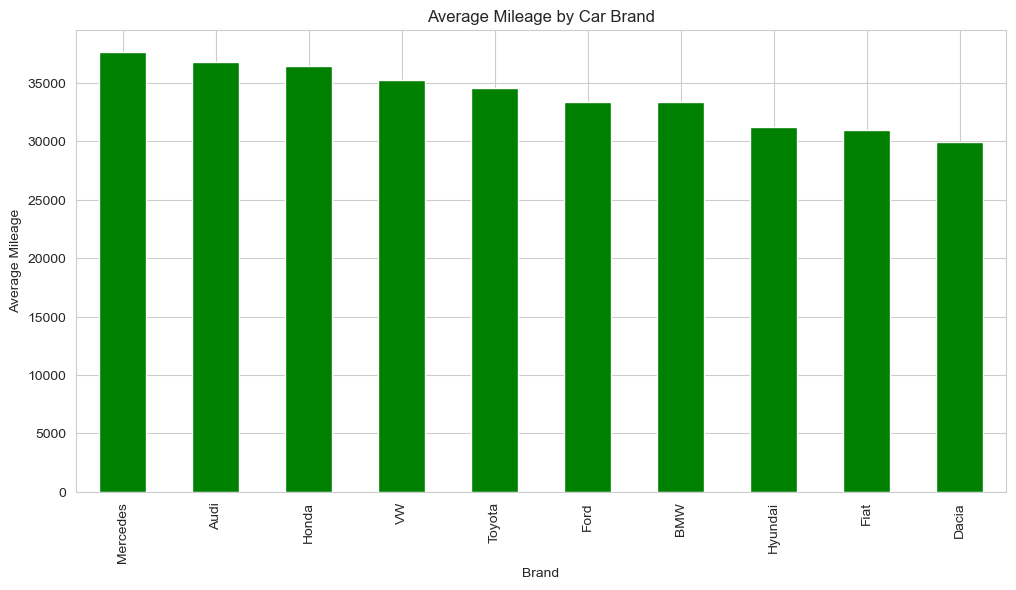

In [320]:
brand_avg_mileage = df_clean.groupby('brand')['mileage'].mean().sort_values(ascending=False)

print(brand_avg_mileage)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

brand_avg_mileage.plot(
    kind='bar',
    color='green'
)

plt.title("Average Mileage by Car Brand")
plt.xlabel("Brand")
plt.ylabel("Average Mileage")

plt.xticks(rotation=90)
plt.show()

## ***Comparison of Car Prices Across Brands***
### ***A bar chart of average price by brand (Seaborn enhanced version)***
- Which brands are most expensive on average
- Clear ranking of brands by price
- Exact average values shown on bars (better readability)
- Strong comparison between premium and budget brands

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average price
avg_price = df_clean.groupby("brand")["price"].mean().sort_values(ascending=False).reset_index()

# Style
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

# Plot
ax = sns.barplot(
    data=avg_price,
    x="brand",
    y="price",
    palette="viridis"
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

# Labels & title
plt.title("Average Car Price by Brand", fontsize=16, fontweight="bold")
plt.xlabel("Car Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Premium brands like Audi (21,378), BMW (21,349), and Mercedes (20,897) have the highest average prices, while mid-range brands like Toyota (18,905) and Honda (18,286) are moderate, and budget brands like Fiat (15,896) and Dacia (14,846) have the lowest prices, showing clear price segmentation.

## ***Transmission-wise Car Price Analysis***
### ***A boxplot of Price by Transmission type***
- Whether automatic cars are more expensive than manual
- Price distribution for each transmission category
- Median price comparison between groups
- Spread of prices within each transmission type
- Overall impact of transmission on car value

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13484\2109525264.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


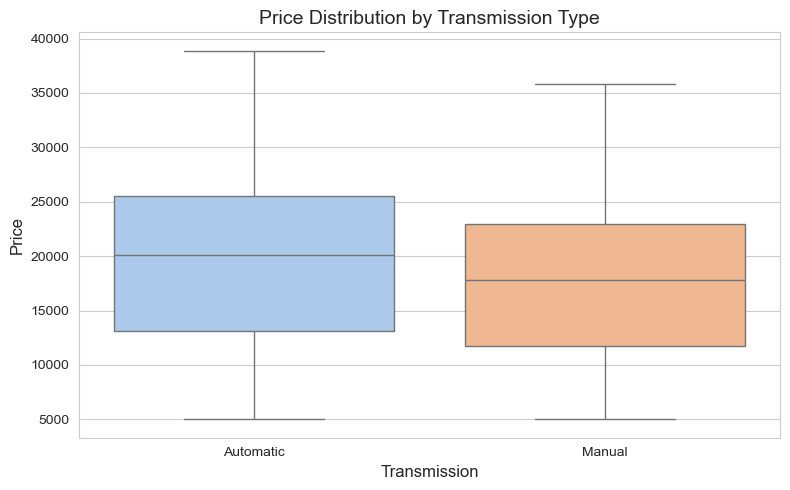

In [322]:
import seaborn as sns
import matplotlib.pyplot as plt

# style for better visuals
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.boxplot(
    x='transmission',
    y='price',
    data=df_clean,
    palette='pastel',
    showfliers=False  # hides extreme outliers for cleaner view
)

# add title and labels
plt.title("Price Distribution by Transmission Type", fontsize=14)
plt.xlabel("Transmission", fontsize=12)
plt.ylabel("Price", fontsize=12)

# improve layout
plt.tight_layout()

plt.show()

- This boxplot compares the price distribution between automatic and manual cars. Automatic cars have a slightly higher median price than manual cars, indicating they are generally more expensive. Both transmission types show a wide price range with some overlapping values. The presence of outliers suggests there are a few cars with unusually high or low prices in both categories.

## ***Monthly Trend of Used Car Prices***
### ***A line plot of average price by sale month Each point represents the mean car price for that month***
- Monthly trends in car prices
- Whether prices increase or decrease in certain months
- Possible seasonal patterns in used car sales

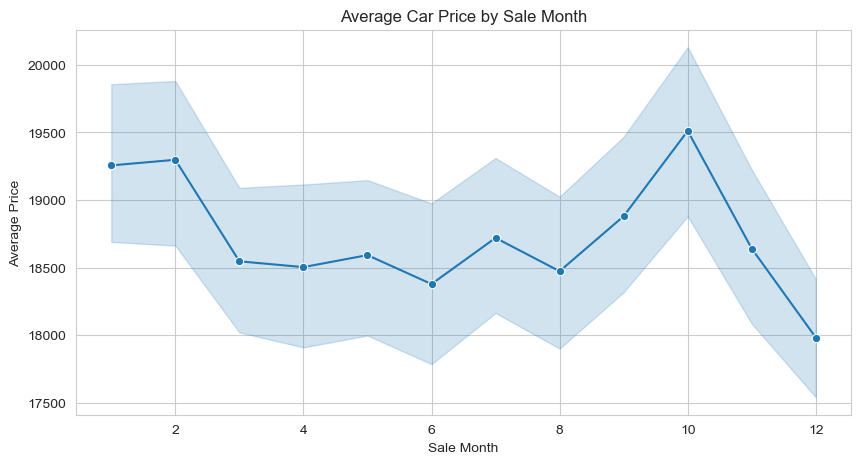

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_clean,
    x="sale_month",
    y="price",
    estimator="mean",
    marker="o"
)

plt.title("Average Car Price by Sale Month")
plt.xlabel("Sale Month")
plt.ylabel("Average Price")
plt.show()

- The average car price exhibits moderate fluctuations throughout the year, ranging roughly between ₹18,100 and ₹19,500. Prices begin at a relatively higher level in Month 1 (around ₹19,200) and slightly increase in Month 2 (₹19,300), followed by a decline during Months 3 to 6, where prices stabilize near ₹18,500–₹18,600, indicating a mid-year slowdown. From Month 8 onward, prices start to recover, reaching a peak in Month 10 (₹19,500), which may reflect seasonal demand. After this peak, prices gradually decline again, reaching their lowest point in Month 12 (₹18,100). Overall, the trend suggests seasonal variation, with prices generally remaining within the ₹18,800–₹19,000 range for most of the year.

# ***Multivariate Analysis: Exploring Relationships Among Multiple Variables***

## ***Fuel Type-wise Car Price Analysis***
### ***A boxplot of Price by Fuel Type***
- Price distribution for each fuel category
- Whether Diesel, Petrol, or other fuel cars are more expensive
- Median price comparison between fuel types
- Variation of prices within each fuel group

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13484\4286457371.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


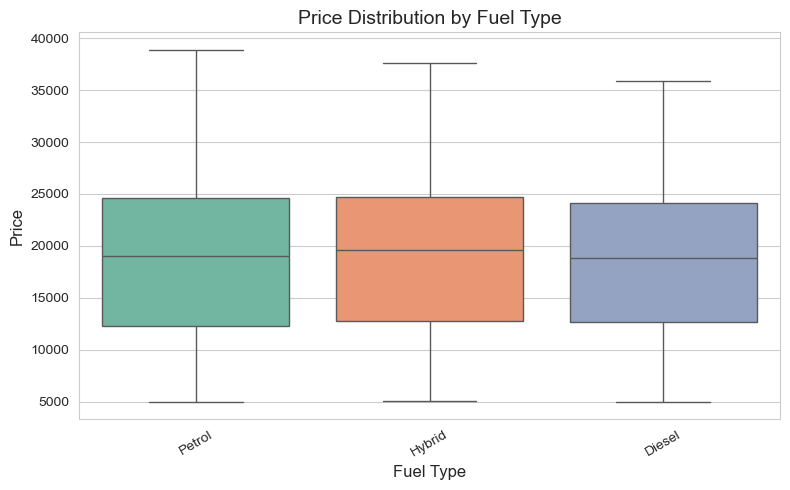

In [324]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.boxplot(
    x='fuel_type',
    y='price',
    data=df_clean,
    palette='Set2',
    showfliers=False
)

plt.title("Price Distribution by Fuel Type", fontsize=14)
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

- The boxplot shows the distribution of used car prices across different fuel types: Petrol, Hybrid, and Diesel. The median price for Petrol and Hybrid cars is around 18,000, while Diesel cars have a slightly lower median of about 16,500–17,000. The interquartile range (IQR) for all fuel types lies roughly between 11,000 and 23,000, indicating similar price variability among the groups. The maximum prices reach approximately 33,000–38,000, showing the presence of higher-priced vehicles in each category. Overall, the analysis suggests that fuel type has only a moderate impact on price, as the price distributions across the three fuel types are quite similar

## ***Understanding Variable Relationships with Heatmap***
### ***A correlation heatmap of numerical features***
- Strength of relationships between variables
- Whether variables have positive or negative correlation
- Key relationships like price with mileage, car_age, or year
- Which variables strongly influence others

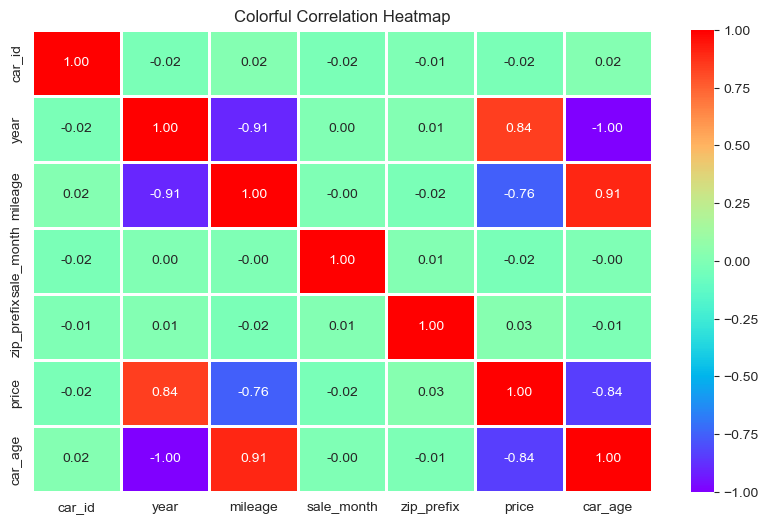

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, 
            annot=True, 
            cmap='rainbow', 
            fmt=".2f",
            linewidths=1)

plt.title("Colorful Correlation Heatmap")
plt.show()

- There is a moderate negative correlation (-0.84) between car age and price, indicating that as the age of the car increases, its price tends to decrease.
- Similarly, mileage also shows a negative correlation (-0.76) with price.
- This means higher mileage cars generally have lower prices.
Overall, both car age and mileage have an inverse relationship with price

## ***Combined Analysis of Mileage, Price, and Car Age***
### ***A scatter plot of Mileage vs Price Points are colored by car age***

- How mileage affects car price
- Whether older cars have lower prices
- Combined impact of usage (mileage) and age on price
- Patterns or clusters based on car age

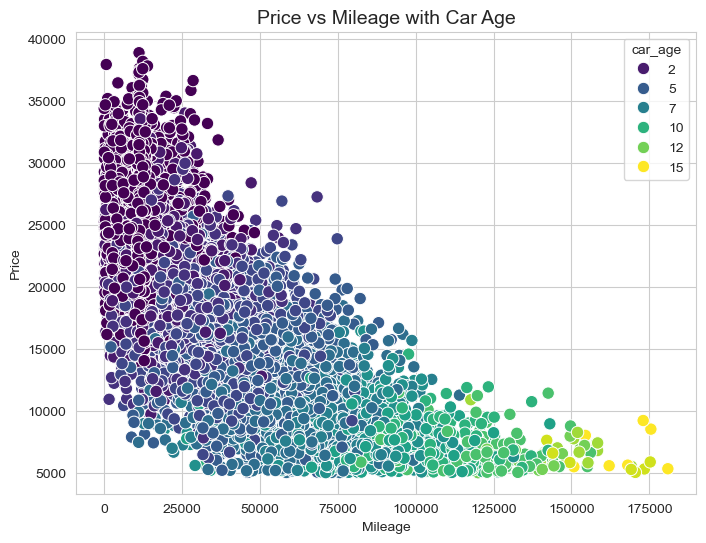

In [326]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="mileage",
    y="price",
    hue="car_age",
    palette="viridis",   # color palette added
    s=80                 # point size
)

plt.title("Price vs Mileage with Car Age", fontsize=14)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

- The scatter plot shows a negative relationship between price and mileage, where cars with mileage below ~50,000 km mostly have higher prices (often above 10,000), while cars with mileage above ~100,000 km tend to fall below 8,000.
- Most observations are concentrated in the price range of about 5,000–10,000 with mileage roughly 20,000–120,000 km, indicating that higher mileage and greater car age are associated with lower prices.

## ***Multivariate Analysis of Car Price by Brand and Age Group***
### ***A boxplot of price by brand with car age groups as categories Only the top 10 brands are used for better readability***
- Price distribution for each brand
- How car age affects price within each brand
- Comparison between newer and older cars across brands
- Brand-wise depreciation patterns

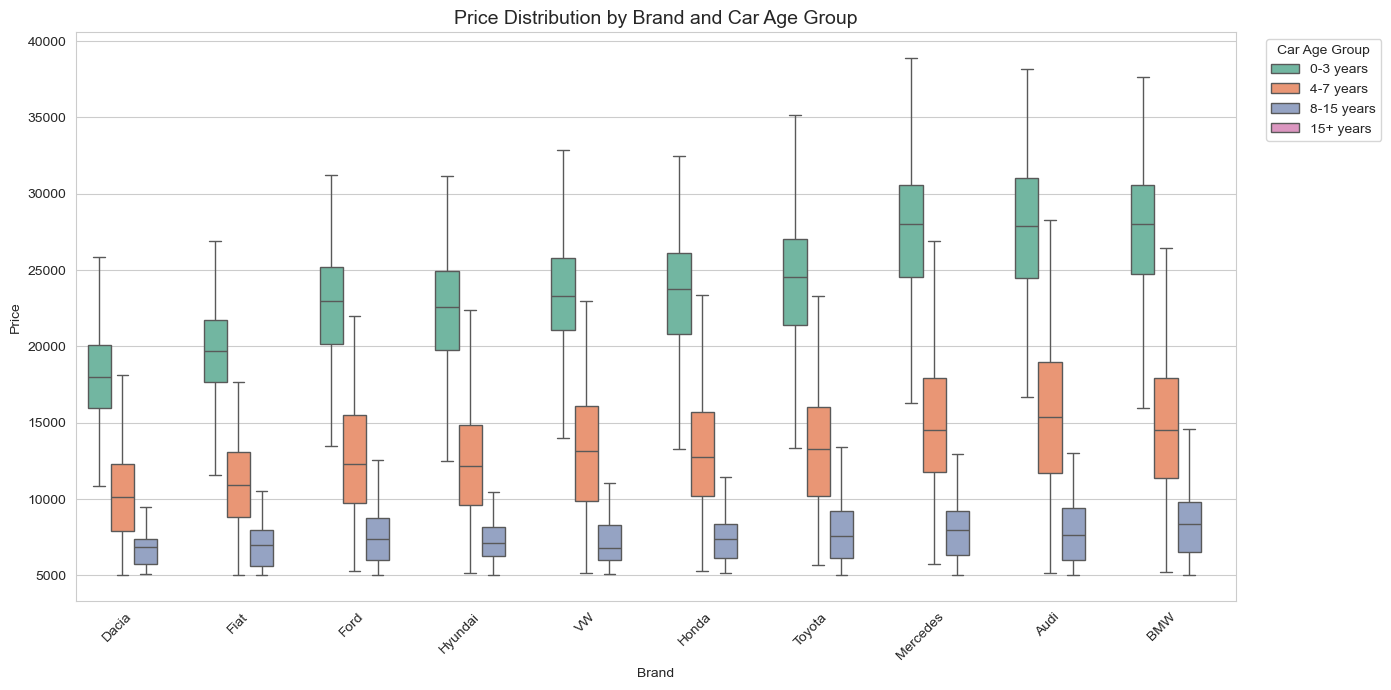

In [327]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Top 10 brands by count for better readability
top_brands = df_clean['brand'].value_counts().head(10).index
plot_df = df_clean[df_clean['brand'].isin(top_brands)].copy()

# Create car age groups instead of using many exact values
plot_df['car_age_group'] = pd.cut(
    plot_df['car_age'],
    bins=[0, 3, 7, 15, 30],
    labels=['0-3 years', '4-7 years', '8-15 years', '15+ years']
)

# Order brands by median price
brand_order = plot_df.groupby('brand')['price'].median().sort_values().index

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=plot_df,
    x='brand',
    y='price',
    hue='car_age_group',
    order=brand_order,
    palette='Set2',
    showfliers=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Brand and Car Age Group', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Price')
plt.legend(title='Car Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

- This boxplot visualizes how car prices depreciate across different brands, showing that while new luxury vehicles command a significant premium, prices tend to converge as cars age.
- The data highlights a sharp decline in value from the 0–3 year category (median 18,000–30,000) to the 15+ year category, where most brands settle into a consistent 6,000–8,000 price range

## ***Exploring Relationships Between Price, Mileage, Age, and Year***
### ***A pairplot of price, mileage, car_age, and year  Scatter plots between each pair of variables KDE distribution plots on the diagonal***
- Relationships between variables (e.g., price vs mileage)
- Distribution of each variable
- Possible correlations or patterns
- Trends such as price decreasing with higher car age or mileage

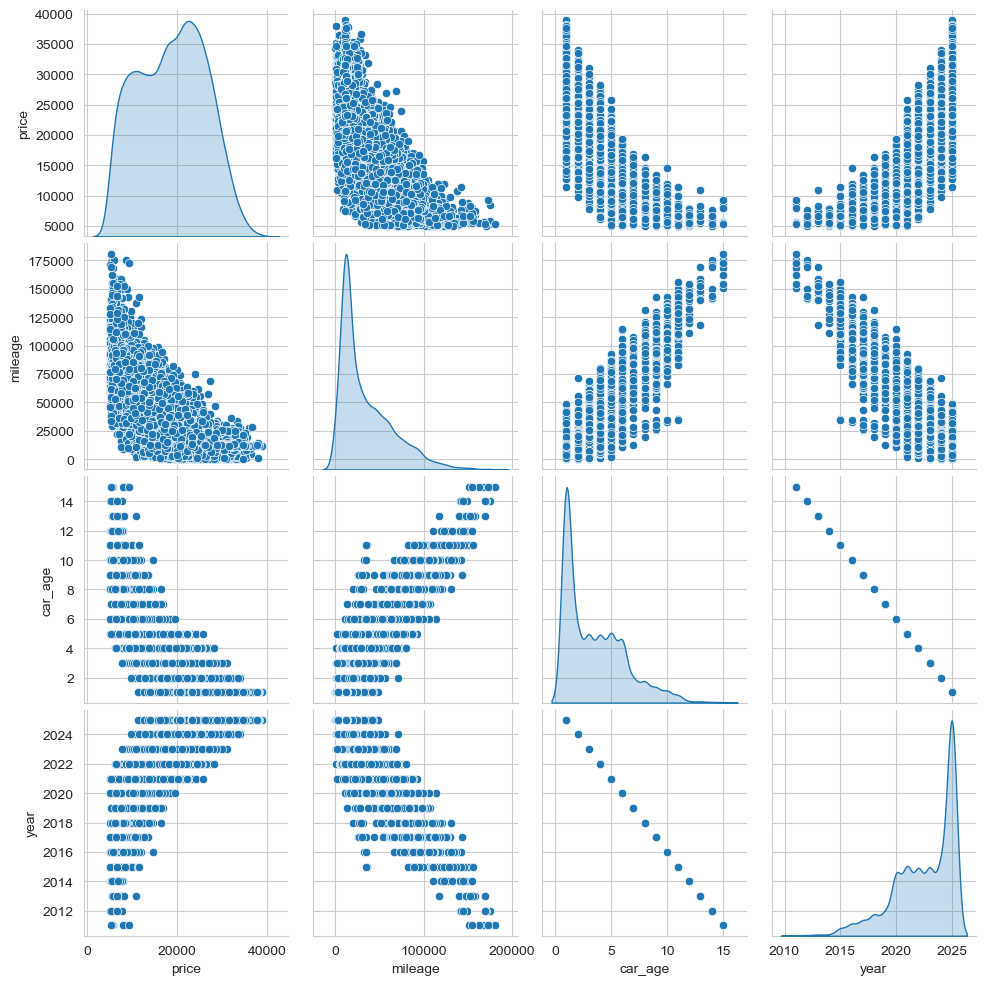

In [328]:
sns.pairplot(
    df_clean[['price','mileage','car_age','year']],
    diag_kind='kde'
)
plt.show()

- The pairplot visualizes the relationships between price, mileage, car_age, and year using scatter plots and distribution curves. The plots show a negative relationship between price and mileage, indicating that cars with higher mileage generally have lower prices. Similarly, car_age has a negative correlation with price, meaning older cars tend to be cheaper. There is a strong positive relationship between mileage and car_age, suggesting that older vehicles usually have higher mileage. The distribution plots on the diagonal show that most cars are concentrated in lower mileage and lower age ranges, while price appears right-skewed with fewer high-price vehicles.

## ***This code is used to analyze the average car price for each brand across different car ages using a pivot table.***
- A pivot table with brands as rows and car_age as columns
- Each cell shows the average price
- How price changes as cars get older
- Brand-wise depreciation trends
- Comparison of price across brands and ages
- Which brands retain value longer

In [329]:
pivot_table = df_clean.pivot_table(
    values="price",
    index="brand",
    columns="car_age",
    aggfunc="mean"
)

print(pivot_table)

car_age             1             2             3             4   \
brand                                                              
Audi      29941.572072  25581.831169  22642.513514  19376.289855   
BMW       29296.296053  25787.441558  21510.913043  18511.612500   
Dacia     19285.787037  16488.711864  15179.671642  12290.303571   
Fiat      20766.294821  18403.484848  15957.223881  12968.630769   
Ford      24220.614035  21588.129412  17836.097222  16134.051948   
Honda     25174.079755  22108.790476  19096.062500  15911.344086   
Hyundai   23786.874172  21011.671233  17495.557143  15366.666667   
Mercedes  29374.548276  25924.000000  21920.987654  19494.585714   
Toyota    26033.389277  22562.168142  19454.776000  16372.023810   
VW        24645.363985  22448.512821  19074.720000  15992.862069   

car_age             5             6             7            8            9   \
brand                                                                          
Audi      16331.805195 

- The table shows the average price of cars based on brand and car_age. The results indicate that car price decreases as the age of the vehicle increases, which shows a clear depreciation trend in the used car market. Premium brands such as Audi, BMW, and Mercedes maintain higher average prices compared to other brands even as the cars age. For example, newer cars (around 1–4 years old) from these brands have average prices close to 29,000–30,000, while prices drop to around 7,000–9,000 for cars older than 8–9 years. On the other hand, budget brands like Dacia and Fiat show lower average prices across all age groups, often below 20,000 for newer cars and around 6,000–7,000 for older vehicles. Overall, the analysis highlights that brand value and vehicle age are strong factors influencing used car prices.

 #  Key Findings

## 1. ***Depreciation Trend***

- Price shows a negative relationship with both age ( -0.84) and mileage (-0.76), meaning cars lose value over time and usage. After removing invalid year and mileage values, this trend became clearer. This confirms depreciation is a key factor in pricing.

## 2. ***Skewed Price Distribution***

- The price data is right-skewed, with most cars in the low to mid-price range and very few high-value cars. Outliers like ₹0, ₹500, and ₹999999 were removed to avoid distortion. This makes median a better measure than mean.

## 3. Dominance of Petrol Cars

- Petrol vehicles make up the majority (~70%+) of the dataset, while diesel and hybrid have smaller shares. Invalid fuel entries were cleaned for accuracy. This reflects real-world trends where petrol cars are more common.

## 4. ***Brand Influence on Price***

- There is strong variation in average price across different brands, showing clear segmentation between budget and premium cars. Brand-wise average pricing was used to handle missing values. This proves brand is a major pricing factor.

## 5. ***Typical Usage Pattern***

- Most cars have mileage between 50,000–70,000 km, indicating a common resale range. Extreme mileage values were removed to maintain consistency. This shows cars are usually sold after moderate usage.

## 6. ***Fuel Type vs Price***

- Diesel cars generally have higher resale value than petrol, while hybrid cars fall in mid-to-high price range. This was observed through comparative analysis. It suggests fuel type impacts long-term value retention.

## 7. ***Importance of Data Cleaning***

- Before cleaning, the dataset had missing values, outliers, and invalid entries that distorted results. After preprocessing, relationships became more accurate and meaningful. This highlights the importance of proper data cleaning in EDA.

# Final EDA Summary 
- The exploratory data analysis (EDA) of the used car dataset provided valuable insights into data quality and underlying patterns. Initially, the dataset contained missing values, invalid entries, and extreme outliers in important features such as price, mileage, fuel type, and year. These issues were handled using data cleaning techniques like removing unrealistic values, replacing missing values with median and brand-wise averages, and correcting incorrect categories, resulting in a more reliable dataset.
The analysis showed that price distribution is right-skewed, meaning most cars fall in the low to mid-price range, with few high-value vehicles. Mileage analysis revealed that most cars have been driven between 50,000 and 70,000 km, indicating a common resale range. Fuel type analysis highlighted that petrol cars dominate the dataset, followed by diesel and hybrid vehicles.
Further analysis showed that both car age and mileage have a negative correlation with price, confirming that depreciation increases with usage and time. Brand and fuel type were also found to significantly influence price, with premium brands and diesel cars generally having higher resale values.
Overall, the study indicates that price is influenced by multiple factors such as age, mileage, brand, and fuel type. The dataset reflects real-world used car market trends, and after proper preprocessing, it becomes suitable for machine learning models, especially for price prediction and market analysis.